## Métricas de Evaluación

Para este problema de negocio (predicción de rotación de empleados) se evaluarán las siguientes métricas:

| Métrica | Descripción | Importancia |
|---|---|---|
| **Accuracy** | Proporción de aciertos totales | General |
| **Precision** | De los predichos positivos, cuántos son correctos | Evitar falsas alarmas |
| **Recall** | De los positivos reales, cuántos se detectaron | Detectar empleados en riesgo |
| **F1-Score** | Media armónica de Precision y Recall | Balance entre ambas |
| **AUC-ROC** | Capacidad de discriminación del modelo | Rendimiento global |

>En este problema el **Recall** es la métrica más importante — es preferible identificar a todos los empleados en riesgo de rotación aunque haya algunas falsas alarmas, ya que el costo de perder un empleado es mayor que el de retenerlo innecesariamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay)

In [2]:
df = pd.read_csv("../data/interim/employee_performance_clean.csv")

X = df.drop(columns=["attrition"])
y = df["attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Distribución target: {Counter(y)}")

✅ Dataset cargado: 14,000 filas × 20 columnas
X_train: (11200, 19) | X_test: (2800, 19)
Distribución target: Counter({0: 11840, 1: 2160})


In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Codificar variables categóricas
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop(columns=["attrition"])
y = df_enc["attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep  = scaler.transform(X_test)

# Balancear con SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print(f"Distribución original:   {Counter(y_train)}")
print(f"Distribución balanceada: {Counter(y_train_bal)}")

# Entrenar modelos
modelos = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "SVM":                 SVC(probability=True, random_state=42),
    "KNN":                 KNeighborsClassifier()
}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    print(f"{nombre} entrenado")

C:\Users\angel\AppData\Local\Temp\ipykernel_13284\1682529197.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc.select_dtypes(include='object').columns:


Distribución original:   Counter({0: 9472, 1: 1728})
Distribución balanceada: Counter({0: 9472, 1: 9472})
Logistic Regression entrenado
Decision Tree entrenado
Random Forest entrenado
SVM entrenado
KNN entrenado


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}
for nombre, modelo in modelos.items():
    scores = cross_validate(modelo, X_train_bal, y_train_bal, cv=cv, scoring=scoring)
    resultados_cv[nombre] = {m: scores[f'test_{m}'].mean() for m in scoring}

df_cv = pd.DataFrame(resultados_cv).T.round(4)
display(df_cv)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.5128,0.5125,0.5270,0.5196,0.5232
Decision Tree,0.8234,0.8132,0.8397,0.8262,0.8234
Random Forest,0.9137,1.0000,0.8275,0.9056,0.9662
SVM,0.7799,0.7478,0.8451,0.7934,0.8585
KNN,0.7315,0.6533,0.9866,0.7861,0.9038



Modelo: Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.50      0.62      2368
           1       0.15      0.48      0.23       432

    accuracy                           0.49      2800
   macro avg       0.49      0.49      0.42      2800
weighted avg       0.73      0.49      0.56      2800


Modelo: Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2368
           1       0.16      0.20      0.18       432

    accuracy                           0.71      2800
   macro avg       0.50      0.50      0.50      2800
weighted avg       0.74      0.71      0.73      2800


Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2368
           1       0.00      0.00      0.00       432

    accuracy                           0.85      2800
   macro avg       0.42      0.50      0.46      2800

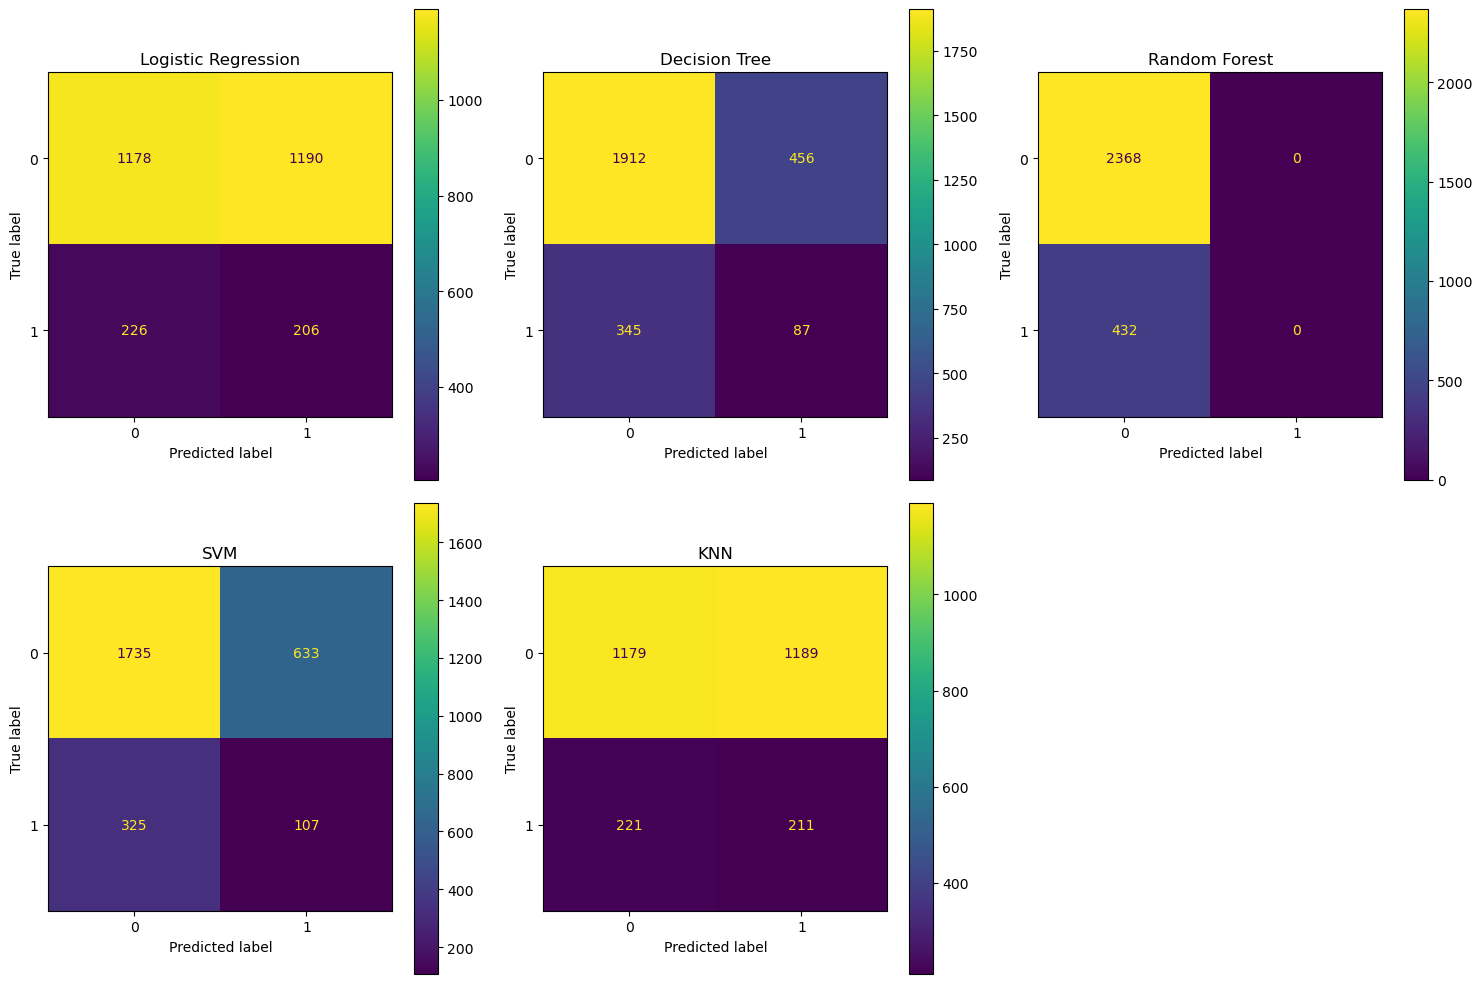

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_test_prep)
    
    print(f"\n{'='*40}")
    print(f"Modelo: {nombre}")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[idx])
    axes[idx].set_title(nombre)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

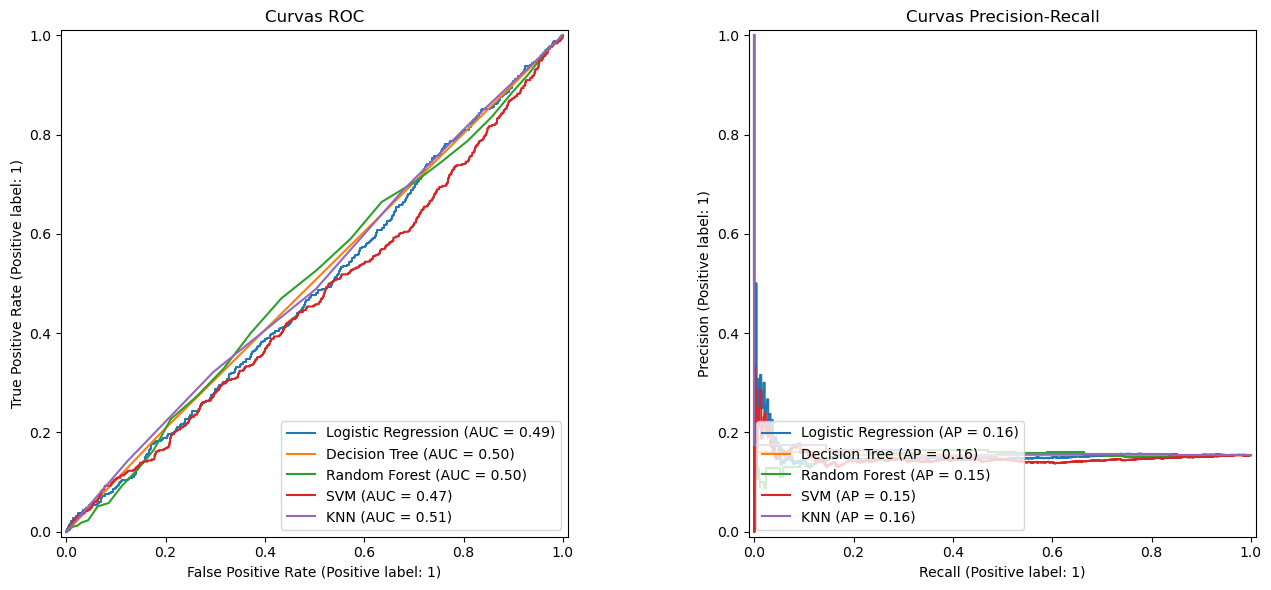

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for nombre, modelo in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_test_prep, y_test,
                                   name=nombre, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(modelo, X_test_prep, y_test,
                                          name=nombre, ax=axes[1])

axes[0].set_title("Curvas ROC")
axes[1].set_title("Curvas Precision-Recall")
plt.tight_layout()
plt.show()

In [17]:
# Resumen de resultados
print("Cross-validation (datos balanceados con SMOTE):")
display(df_cv)
print("Mejor modelo por AUC-ROC en CV: Random Forest (0.9662)")
print("Nota: Las métricas en test son bajas debido al")
print("desbalance de clases (84% No rotó vs 16% Sí rotó).")
print("Se recomienda ajuste de threshold o técnicas")
print("adicionales de balanceo en el siguiente sprint.")

Cross-validation (datos balanceados con SMOTE):


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.5128,0.5125,0.5270,0.5196,0.5232
Decision Tree,0.8234,0.8132,0.8397,0.8262,0.8234
Random Forest,0.9137,1.0000,0.8275,0.9056,0.9662
SVM,0.7799,0.7478,0.8451,0.7934,0.8585
KNN,0.7315,0.6533,0.9866,0.7861,0.9038


Mejor modelo por AUC-ROC en CV: Random Forest (0.9662)
Nota: Las métricas en test son bajas debido al
desbalance de clases (84% No rotó vs 16% Sí rotó).
Se recomienda ajuste de threshold o técnicas
adicionales de balanceo en el siguiente sprint.
